In [1]:
import pandas as pd
import numpy as np
from pandas import DataFrame
import glob
import os

import matplotlib.pyplot as plt
import seaborn as sns

# Part I - Read in the Data

In [2]:
path=r'C:\Users\aleci\Documents\Project 6 - Credit Card Fraud Detection\data\\'

df=pd.read_csv(path+'creditcard.csv')

# Part 2 - Determine what columns to use for generating clusters
* Kmeans is based on euclidean distance, so only numeric values can be used. 
* some character varibales can be transformed to numeric varlues. 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
# get some descriptive statistics for numeric values 
# Transpose the output for a easier viewing
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,3.918649e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,5.682686e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-8.761736e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.811118e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,-1.552103e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,2.040130e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-1.698953e-15,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,-1.893285e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-3.147640e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [5]:
# check null values to see whether any cleaning needs to be done
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
x=df.drop('Class', axis=1)
y=df['Class']

In [7]:
x.shape, y.shape

((284807, 30), (284807,))

In [9]:
# split the sample into train and test sets
from sklearn.model_selection import train_test_split

df['random']=np.random.uniform(0, 1, len(df['Time']))
df['seg']=np.where(df['random'] <= 0.7, 'mod', 'val')

Xlist=['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
'V11','V12','V13','V14','V15','V16','V17','V18','V19','V20','V21','V22','V23','V24','V25','V26','V27','V28','Amount']

Xylist=['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
'V11','V12','V13','V14','V15','V16','V17','V18','V19','V20','V21','V22','V23','V24','V25','V26','V27','V28', 'Amount', 'Class']


modelsample=df[df['seg']=='mod'][Xylist].fillna(0)
valsample=df[df['seg']=='val'][Xylist].fillna(0)

In [10]:
modelsample[Xlist].describe().T

,count,mean,std,min,25%,50%,75%,max
Time,199721.0,94896.326996,47506.006034,0.000000,54256.000000,84859.000000,139422.000000,172792.000000
V1,199721.0,-0.000046,1.956047,-56.407510,-0.920022,0.015458,1.314755,2.454930
V2,199721.0,-0.001109,1.660444,-72.715728,-0.596972,0.066334,0.806388,18.183626
V3,199721.0,0.000641,1.507925,-48.325589,-0.890807,0.179705,1.026225,4.069865
V4,199721.0,-0.000536,1.413929,-5.600607,-0.847155,-0.020248,0.740816,16.875344
V5,199721.0,-0.001592,1.377900,-113.743307,-0.692078,-0.054619,0.611138,34.801666
V6,199721.0,-0.001188,1.334689,-26.160506,-0.769642,-0.274547,0.393105,73.301626
V7,199721.0,0.005514,1.235549,-31.764946,-0.552330,0.042224,0.572908,120.589494
V8,199721.0,0.000604,1.182408,-73.216718,-0.209718,0.021011,0.326469,19.587773
V9,199721.0,0.001532,1.097011,-9.462573,-0.641865,-0.049724,0.599255,10.392889


In [11]:
# standardize the variables
# It is very important to make a copy of the modeling sample and use the copy to calculate mean and std. 

# standardize the variable
modsamp=modelsample.copy()

def standardize(x, samp):
    x_mean=modsamp[x].mean()
    x_std=modsamp[x].std()
    
    x_standardized=(samp[x]-x_mean)/x_std
    return x_standardized

for item in Xlist:
    modelsample[item]=standardize(item, modelsample)
    valsample[item]=standardize(item, valsample)
    
# normalize the variable between 0 and 1  
modsamp2=modelsample.copy()

def scaler(x, samp):
    x_max=modsamp2[x].max()
    x_min=modsamp2[x].min()
    
    x_standardized=(samp[x]-x_min)/(x_max-x_min)
    return x_standardized

for item in Xlist:
    modelsample[item]=scaler(item, modelsample)
    valsample[item]=scaler(item, valsample)

In [12]:
modelsample[Xlist].describe().T

,count,mean,std,min,25%,50%,75%,max
Time,199721.0,0.549194,0.274932,0.0,0.313996,0.491105,0.806878,1.0
V1,199721.0,0.958293,0.033231,0.0,0.942664,0.958556,0.980630,1.0
V2,199721.0,0.799946,0.018267,0.0,0.793391,0.800688,0.808830,1.0
V3,199721.0,0.922336,0.028780,0.0,0.905322,0.925754,0.941910,1.0
V4,199721.0,0.249158,0.062909,0.0,0.211491,0.248281,0.282143,1.0
V5,199721.0,0.765706,0.009276,0.0,0.761057,0.765349,0.769830,1.0
V6,199721.0,0.263008,0.013419,0.0,0.255282,0.260259,0.266972,1.0
V7,199721.0,0.208530,0.008110,0.0,0.204868,0.208771,0.212254,1.0
V8,199721.0,0.788942,0.012741,0.0,0.786675,0.789161,0.792453,1.0
V9,199721.0,0.476650,0.055250,0.0,0.444246,0.474069,0.506754,1.0


In [13]:
valsample[Xlist].describe().T

,count,mean,std,min,25%,50%,75%,max
Time,85086.0,0.547596,0.274584,0.000000,0.312957,0.489048,0.805014,0.999977
V1,85086.0,0.958296,0.033381,0.328787,0.942646,0.958693,0.980686,0.999948
V2,85086.0,0.799987,0.017928,0.103092,0.793334,0.800664,0.808728,1.042620
V3,85086.0,0.922295,0.029309,0.279501,0.905354,0.925764,0.941966,1.101396
V4,85086.0,0.249238,0.063197,-0.003673,0.211254,0.248334,0.282524,0.992890
V5,85086.0,0.765741,0.009329,0.554624,0.761070,0.765353,0.769845,0.987275
V6,85086.0,0.263048,0.013338,0.042541,0.255326,0.260271,0.267155,0.467917
V7,85086.0,0.208409,0.008143,-0.077400,0.204834,0.208721,0.212197,0.411295
V8,85086.0,0.788920,0.013167,0.346669,0.786713,0.789206,0.792484,1.004520
V9,85086.0,0.476392,0.055523,-0.200020,0.444046,0.473862,0.506382,1.261999


In [15]:
print("model sample avg fraud rate: {}".format(modelsample['Class'].mean()))
print("validation sample avg fraud rate: {}".format(valsample['Class'].mean()))
print("model sample total fraud count: {}".format(modelsample['Class'].sum()))

model sample avg fraud rate: 0.0016923608433765103
validation sample avg fraud rate: 0.0018099334790682368
model sample total fraud count: 338


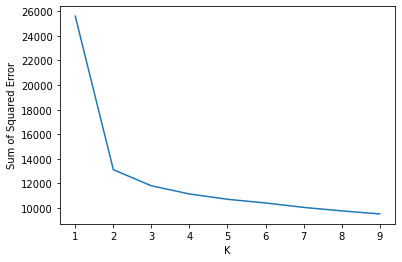

In [16]:
# deterine k value
from sklearn.cluster import KMeans

sse=[]

for k in range(1, 10):
    model=KMeans(n_clusters=k)
    model.fit(modelsample.drop('Class', axis=1))
    sse.append(model.inertia_)
    
x=range(1, 10)
y=sse

plt.xlabel('K')
plt.ylabel('Sum of Squared Error')
plt.plot(x, y)

* 2 clusters seem enough, but we can try 3.
* If we select 3 clusters, we will expect 2 of them will show similar performance.

In [24]:
model=KMeans(n_clusters=3)
model.fit(modelsample.drop('Class', axis=1))

y_pred=model.predict(modelsample.drop('Class', axis=1))

modelsample['cluster']=y_pred

modelsample_sum=modelsample.groupby('cluster')['Class'].agg(['count', 'sum', 'mean'])
modelsample_sum=modelsample.groupby('cluster')['Class'].agg(model_count='count',
                                                            model_sum='sum',
                                                            model_mean='mean')
modelsample_sum['model_count_pct']=modelsample_sum['model_count']/(modelsample_sum['model_count'].sum())


# Check on the validation sample
y_pred_val=model.predict(valsample.drop('Class', axis=1))

valsample['cluster']=y_pred_val

valsample_sum=valsample.groupby('cluster')['Class'].agg(['count', 'sum', 'mean'])
valsample_sum=valsample.groupby('cluster')['Class'].agg(val_count='count',
                                                        val_sum='sum',
                                                        val_mean='mean')
valsample_sum['val_count_pct']=valsample_sum['val_count']/(valsample_sum['val_count'].sum())


# merge the two summaries
mod_val_sum=pd.merge(modelsample_sum, valsample_sum, on='cluster', how='outer').reset_index()
mod_val_sum

,cluster,model_count,model_sum,model_mean,model_count_pct,val_count,val_sum,val_mean,val_count_pct
0,0,62450,119,0.001906,0.312686,26646,57,0.002139,0.313166
1,1,90119,92,0.001021,0.451224,38220,47,0.001230,0.449193
2,2,47152,127,0.002693,0.236089,20220,50,0.002473,0.237642


C:\Users\aleci\AppData\Local\Temp/ipykernel_20056/3692878169.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels([f'{x:.1%}' for x in plt.gca().get_yticks()])


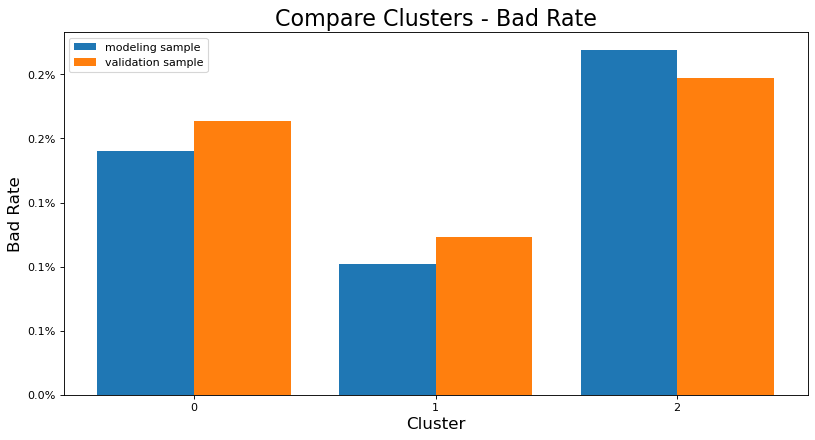

In [25]:
from matplotlib.pyplot import figure
import matplotlib.ticker as mtick  # for formating y axis

figure(figsize=(12, 6), dpi=80)

clusters=[0, 1, 2]
x_axis=np.arange(len(clusters))

plt.bar(x_axis -0.2, mod_val_sum['model_mean'], width=0.4, label = 'modeling sample')
plt.bar(x_axis +0.2, mod_val_sum['val_mean'], width=0.4, label = 'validation sample')
plt.xticks(x_axis, clusters)
plt.xlabel("Cluster", fontsize=15)
plt.gca().set_yticklabels([f'{x:.1%}' for x in plt.gca().get_yticks()]) 
plt.ylabel("Bad Rate", fontsize=15, )
# plt.ylim([20, 80])  # we set this range from 20 in order to accentuate the difference between two periods
plt.title("Compare Clusters - Bad Rate", fontsize=20)
plt.legend(loc='best')
plt.show()

#### Conclusion:
* No single cluster shows much higher % fraud than other clusters.
* Inconsistent performance between modeling sample and validation sample. 
#### The K means clustering does not work in this case. 